# 🎼 Wagner Leitmotif Pattern Recognition — Real Data Demo

**Research Area:** Computational Musicology — Musical Pattern Discovery  
**Framework:** Python + music21  
**Date:** March 2026

---

## Abstract

This notebook runs a complete **musical pattern discovery and matching pipeline** on **real MusicXML data**:

- **10 Wagner leitmotifs** (Ring, Sword, Ride of the Valkyries, Forest Murmurs, etc.)
- **70 film composer scores** across 5 composers: Morricone, Korngold, Shore, Williams, Steiner

### Methodology (Janssen et al. 2013)

| Strategy | Description |
|---|---|
| Exact match | Sliding-window interval search (transposition-invariant) |
| Approximate match | Levenshtein edit distance ≤ 2 |
| Contour match | Melodic direction (-1/0/+1) per Dowling 1978 |

### Musicological Hypothesis

| Composer | Known Wagner Influence | Expected Leitmotif Density |
|---|---|---|
| Korngold | Very High (direct lineage) | High |
| Steiner | High (Golden Age Hollywood) | Medium–High |
| Williams | Medium–High (neo-Romantic) | Medium |
| Shore | High (LOTR explicitly Wagnerian) | High |
| Morricone | Low–Medium (idiosyncratic style) | Low |

In [1]:
# Cell 01 — Imports
import os
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from music21 import converter, interval, stream, note, chord, duration, metadata
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print("All imports successful.")
import music21
print(f"music21 version: {music21.__version__}")

All imports successful.
music21 version: 9.9.1


In [2]:
# Cell 02 — Configure real data paths
NOTEBOOK_DIR = Path(os.path.abspath(''))
LEIT_DIR = str(NOTEBOOK_DIR / 'leitmotifs')
SCORE_DIR = str(NOTEBOOK_DIR / 'scores')
OUTPUT_DIR = str(NOTEBOOK_DIR / 'real_data_output')

COMPOSER_NAMES = ['ennio_morricone', 'erich_wolfgang_korngold', 'howard_shore',
                  'john_williams', 'max_steiner']

# Verify data exists
leit_files = sorted(Path(LEIT_DIR).glob('*.musicxml'))
print(f"Leitmotif directory: {LEIT_DIR}")
print(f"  Found {len(leit_files)} leitmotif files:")
for f in leit_files:
    print(f"    - {f.name}")

print(f"\nScore directory: {SCORE_DIR}")
total_scores = 0
for cdir in sorted(Path(SCORE_DIR).iterdir()):
    if cdir.is_dir():
        scores = list(cdir.glob('*.musicxml'))
        total_scores += len(scores)
        print(f"  {cdir.name}: {len(scores)} scores")
print(f"  Total: {total_scores} scores")

Leitmotif directory: /Users/yalu/wagner-leitmotif-film-composer-scores/leitmotifs
  Found 10 leitmotif files:
    - ForestMurmurs_motif.musicxml
    - Horn_motif.musicxml
    - Mime_motif.musicxml
    - NibelungsHate_motif.musicxml
    - Nibelungs_motif.musicxml
    - Ride_motif.musicxml
    - Ring_motif.musicxml
    - SiblingsLove_motif.musicxml
    - SwirlingBlaze_motif.musicxml
    - Sword_motif.musicxml

Score directory: /Users/yalu/wagner-leitmotif-film-composer-scores/scores
  ennio_morricone: 19 scores
  erich_wolfgang_korngold: 13 scores
  howard_shore: 8 scores
  john_williams: 15 scores
  max_steiner: 15 scores
  Total: 70 scores


## Section 1 — Music Representation

Following Janssen et al. (2013), we extract multiple parallel representations:

| Representation | Description | Property |
|---|---|---|
| MIDI pitch | Absolute pitch as MIDI number | Pitch-specific |
| Interval | Semitone distance between consecutive notes | **Transposition-invariant** |
| Contour | Direction only: -1, 0, +1 | **Shape-based** |
| Rhythm | Duration in quarter-note units | Time-domain |
| Combined | (interval, rhythm) tuples | Multi-dimensional |

In [3]:
# Cell 04 — extract_representations()

def extract_representations(path):
    """
    Extract multiple music representations from a MusicXML file.
    Returns dict with keys: 'midi', 'interval', 'contour', 'rhythm', 'combined', 'notes', 'path'
    """
    score = converter.parse(path)
    part = score.parts[0].flatten()

    notes_list = []
    for el in part.notesAndRests:
        if isinstance(el, note.Note):
            notes_list.append(el)
        elif isinstance(el, chord.Chord):
            top_note = note.Note(el.pitches[-1])
            top_note.duration = el.duration
            notes_list.append(top_note)

    if len(notes_list) < 2:
        raise ValueError(f"Too few notes in {path}")

    midi_seq = [n.pitch.midi for n in notes_list]

    interval_seq = []
    for i in range(len(notes_list) - 1):
        try:
            iv = interval.Interval(noteStart=notes_list[i], noteEnd=notes_list[i+1])
            interval_seq.append(iv.semitones)
        except Exception:
            interval_seq.append(midi_seq[i+1] - midi_seq[i])

    contour_seq = [
        0 if interval_seq[i] == 0 else (1 if interval_seq[i] > 0 else -1)
        for i in range(len(interval_seq))
    ]

    rhythm_seq = [float(n.duration.quarterLength) for n in notes_list]
    combined_seq = list(zip(interval_seq, rhythm_seq[:-1]))

    return {
        'midi': midi_seq,
        'interval': interval_seq,
        'contour': contour_seq,
        'rhythm': rhythm_seq,
        'combined': combined_seq,
        'notes': notes_list,
        'path': path
    }

# Demo: extract representations from the Sword motif
demo_path = os.path.join(LEIT_DIR, 'Sword_motif.musicxml')
demo_repr = extract_representations(demo_path)
print(f"Leitmotif: Sword_motif")
print(f"  MIDI pitches : {demo_repr['midi']}")
print(f"  Intervals    : {demo_repr['interval']}")
print(f"  Contour      : {demo_repr['contour']}")
print(f"  Rhythm       : {demo_repr['rhythm']}")
print(f"  Combined     : {demo_repr['combined']}")

Leitmotif: Sword_motif
  MIDI pitches : [67, 72, 60, 64, 67, 72, 76]
  Intervals    : [5, -12, 4, 3, 5, 4]
  Contour      : [1, -1, 1, 1, 1, 1]
  Rhythm       : [0.5, 2.0, 1.75, 0.25, 1.5, 0.5, 2.0]
  Combined     : [(5, 0.5), (-12, 2.0), (4, 1.75), (3, 0.25), (5, 1.5), (4, 0.5)]


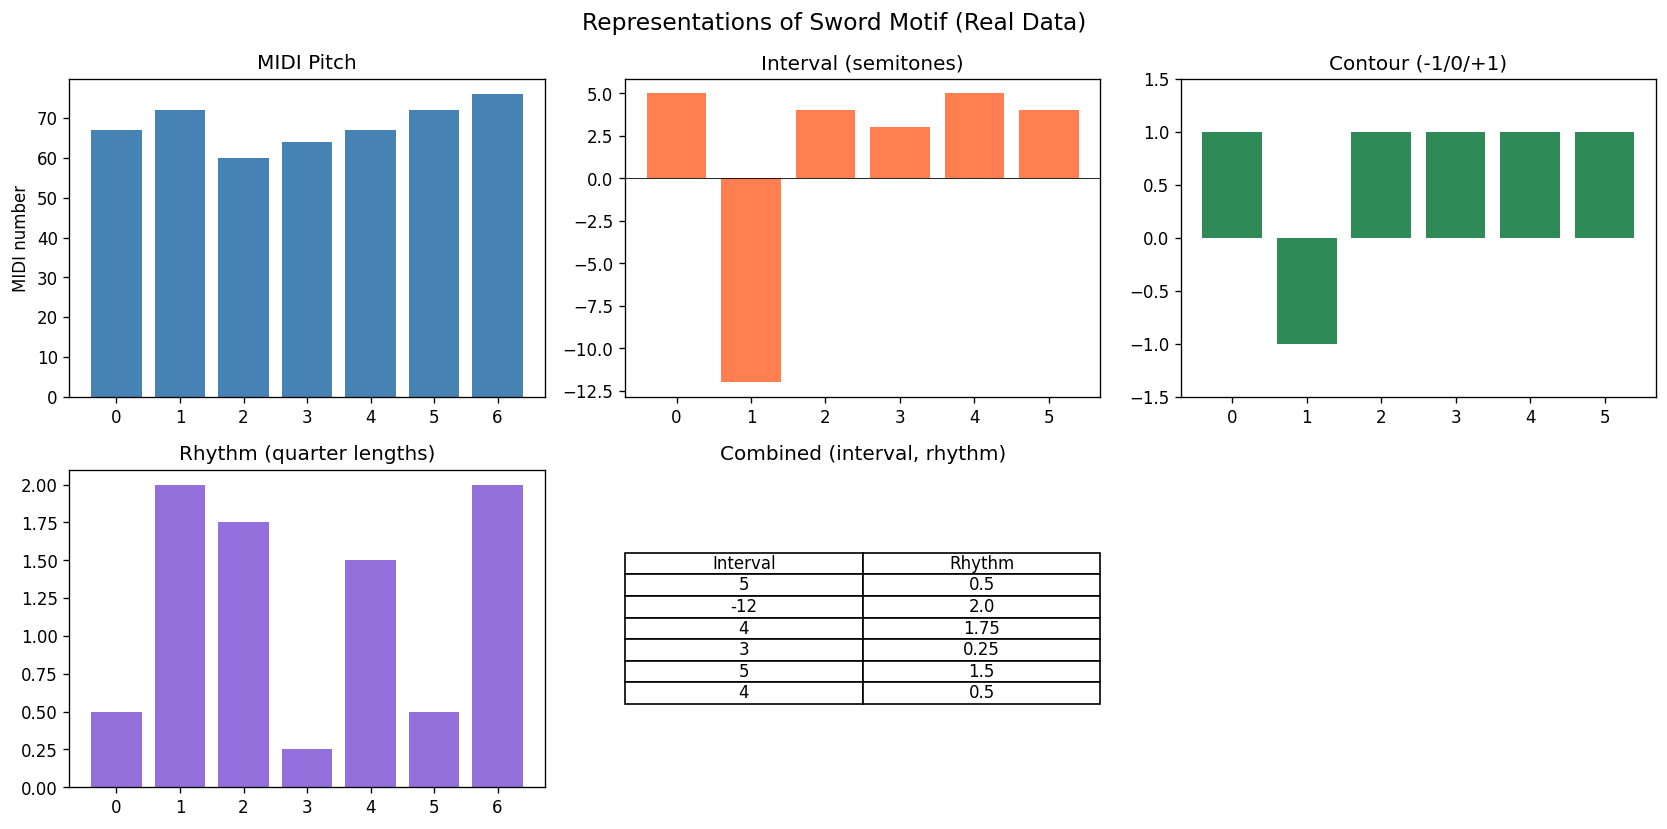

Representation  Length                               Sample
          midi       7                  [67, 72, 60, 64]...
      interval       6                    [5, -12, 4, 3]...
       contour       6                     [1, -1, 1, 1]...
        rhythm       7            [0.5, 2.0, 1.75, 0.25]...
      combined       6 [(5, 0.5), (-12, 2.0), (4, 1.75)]...


In [4]:
# Cell 05 — Visualise all 5 representations of the Sword motif

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Representations of Sword Motif (Real Data)', fontsize=14)

axes[0,0].bar(range(len(demo_repr['midi'])), demo_repr['midi'], color='steelblue')
axes[0,0].set_title('MIDI Pitch')
axes[0,0].set_ylabel('MIDI number')

axes[0,1].bar(range(len(demo_repr['interval'])), demo_repr['interval'], color='coral')
axes[0,1].set_title('Interval (semitones)')
axes[0,1].axhline(0, color='black', linewidth=0.5)

axes[0,2].bar(range(len(demo_repr['contour'])), demo_repr['contour'], color='seagreen')
axes[0,2].set_title('Contour (-1/0/+1)')
axes[0,2].set_ylim(-1.5, 1.5)

axes[1,0].bar(range(len(demo_repr['rhythm'])), demo_repr['rhythm'], color='mediumpurple')
axes[1,0].set_title('Rhythm (quarter lengths)')

axes[1,1].axis('off')
table_data = [[f"{iv}", f"{r}"] for iv, r in demo_repr['combined']]
table = axes[1,1].table(cellText=table_data, colLabels=['Interval', 'Rhythm'],
                         loc='center', cellLoc='center')
table.auto_set_font_size(True)
axes[1,1].set_title('Combined (interval, rhythm)')

axes[1,2].axis('off')

plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'Representation': ['midi', 'interval', 'contour', 'rhythm', 'combined'],
    'Length': [len(demo_repr['midi']), len(demo_repr['interval']),
               len(demo_repr['contour']), len(demo_repr['rhythm']),
               len(demo_repr['combined'])],
    'Sample': [str(demo_repr['midi'][:4])+'...', str(demo_repr['interval'][:4])+'...',
               str(demo_repr['contour'][:4])+'...', str(demo_repr['rhythm'][:4])+'...',
               str(demo_repr['combined'][:3])+'...']
})
print(summary.to_string(index=False))

In [5]:
# Cell 06 — Load ALL leitmotifs and display their representations

leitmotif_reprs = {}
for lf in sorted(Path(LEIT_DIR).glob('*.musicxml')):
    try:
        r = extract_representations(str(lf))
        leitmotif_reprs[lf.stem] = r
        print(f"  ✓ {lf.stem:30s}  notes={len(r['midi']):3d}  intervals={len(r['interval']):3d}  contour_len={len(r['contour']):3d}")
    except Exception as e:
        print(f"  ✗ {lf.stem}: {e}")

print(f"\nSuccessfully loaded {len(leitmotif_reprs)} / {len(leit_files)} leitmotifs")

  ✓ ForestMurmurs_motif             notes= 48  intervals= 47  contour_len= 47
  ✓ Horn_motif                      notes= 11  intervals= 10  contour_len= 10
  ✓ Mime_motif                      notes=  4  intervals=  3  contour_len=  3
  ✓ NibelungsHate_motif             notes= 13  intervals= 12  contour_len= 12
  ✓ Nibelungs_motif                 notes=  9  intervals=  8  contour_len=  8
  ✓ Ride_motif                      notes=  6  intervals=  5  contour_len=  5
  ✓ Ring_motif                      notes=  8  intervals=  7  contour_len=  7
  ✓ SiblingsLove_motif              notes=  7  intervals=  6  contour_len=  6
  ✓ SwirlingBlaze_motif             notes=  6  intervals=  5  contour_len=  5
  ✓ Sword_motif                     notes=  7  intervals=  6  contour_len=  6

Successfully loaded 10 / 10 leitmotifs


## Section 2 — Pattern Matching Engine

Three complementary matching strategies:

1. **Exact match** (interval-based, transposition-invariant): sliding window, O(n·m)
2. **Approximate match** (Levenshtein edit distance): tolerates insertions/deletions/substitutions  
   *Skipped for patterns >20 intervals (e.g., ForestMurmurs) to avoid quadratic blowup*
3. **Contour match** (shape-based): captures melodic direction regardless of interval size

In [6]:
# Cell 08 — Pattern matching functions

def levenshtein_distance(seq1, seq2, max_dist=None):
    """Levenshtein distance with optional early termination."""
    m, n = len(seq1), len(seq2)
    if max_dist is not None and abs(m - n) > max_dist:
        return max_dist + 1
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1): dp[i][0] = i
    for j in range(n + 1): dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if seq1[i-1] == seq2[j-1] else 1
            dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1, dp[i-1][j-1]+cost)
        if max_dist is not None and min(dp[i]) > max_dist:
            return max_dist + 1
    return dp[m][n]

def find_exact_matches(leitmotif_repr, score_repr, rep_type='interval'):
    """Sliding-window exact match."""
    pattern = leitmotif_repr[rep_type]
    text = score_repr[rep_type]
    n = len(pattern)
    matches = []
    for i in range(len(text) - n + 1):
        if text[i:i+n] == pattern:
            matches.append({
                'start_note_idx': i, 'end_note_idx': i + n,
                'match_type': 'exact', 'similarity': 1.0,
                'representation': rep_type
            })
    return matches

def find_approximate_matches(leitmotif_repr, score_repr, rep_type='interval', max_distance=2):
    """Sliding-window approximate match using Levenshtein distance."""
    pattern = leitmotif_repr[rep_type]
    text = score_repr[rep_type]
    n = len(pattern)
    matches = []
    if n > 20:
        return matches
    for i in range(len(text) - n + 1):
        window = text[i:i+n]
        dist = levenshtein_distance(pattern, window, max_dist=max_distance)
        if 0 < dist <= max_distance:
            similarity = 1.0 - (dist / n)
            matches.append({
                'start_note_idx': i, 'end_note_idx': i + n,
                'match_type': 'approximate', 'edit_distance': dist,
                'similarity': round(similarity, 4),
                'representation': rep_type
            })
    return sorted(matches, key=lambda x: x['similarity'], reverse=True)

def find_contour_matches(leitmotif_repr, score_repr, min_similarity=0.75):
    """Contour-based sliding-window match."""
    pattern = leitmotif_repr['contour']
    text = score_repr['contour']
    n = len(pattern)
    matches = []
    if n == 0:
        return matches
    for i in range(len(text) - n + 1):
        window = text[i:i+n]
        agreements = sum(1 for a, b in zip(pattern, window) if a == b)
        similarity = agreements / n
        if similarity >= min_similarity:
            matches.append({
                'start_note_idx': i, 'end_note_idx': i + n,
                'match_type': 'contour', 'similarity': round(similarity, 4),
                'representation': 'contour'
            })
    return sorted(matches, key=lambda x: x['similarity'], reverse=True)

print("✅ All matching functions defined.")

✅ All matching functions defined.


In [7]:
# Cell 09 — Demo: Sword motif vs. Korngold's Robin Hood Finale

demo_score_path = os.path.join(SCORE_DIR, 'erich_wolfgang_korngold',
                                'The Adventures of Robin Hood -  Finale.musicxml')
demo_score_repr = extract_representations(demo_score_path)

leit_repr = leitmotif_reprs['Sword_motif']

print(f"Score : Robin Hood Finale ({len(demo_score_repr['midi'])} notes)")
print(f"Motif : Sword_motif ({len(leit_repr['midi'])} notes)")
print()

exact = find_exact_matches(leit_repr, demo_score_repr, 'interval')
print(f"Exact matches (interval): {len(exact)}")
for m in exact[:5]:
    print(f"  idx {m['start_note_idx']}-{m['end_note_idx']}, sim={m['similarity']}")

approx = find_approximate_matches(leit_repr, demo_score_repr, 'interval', max_distance=2)
print(f"\nApproximate matches (interval, dist≤2): {len(approx)}")
for m in approx[:5]:
    print(f"  idx {m['start_note_idx']}-{m['end_note_idx']}, sim={m['similarity']}, dist={m['edit_distance']}")

contour = find_contour_matches(leit_repr, demo_score_repr, min_similarity=0.80)
print(f"\nContour matches (sim≥0.80): {len(contour)}")
for m in contour[:5]:
    print(f"  idx {m['start_note_idx']}-{m['end_note_idx']}, sim={m['similarity']}")

Score : Robin Hood Finale (857 notes)
Motif : Sword_motif (7 notes)

Exact matches (interval): 0

Approximate matches (interval, dist≤2): 0

Contour matches (sim≥0.80): 84
  idx 249-255, sim=1.0
  idx 262-268, sim=1.0
  idx 305-311, sim=1.0
  idx 318-324, sim=1.0
  idx 441-447, sim=1.0


## Section 3 — Filtering

Following Janssen et al. (2013), we apply filtering to reduce trivial pattern matches:

1. **Similarity threshold**: discard matches below a minimum similarity
2. **Non-overlapping**: keep only the highest-scoring match when windows overlap
3. **Top-N**: limit output to the most significant results

In [8]:
# Cell 11 — filter_matches() definition + demo

def filter_matches(matches, min_similarity=0.80, top_n=20):
    """Filter by threshold, remove overlaps, return top N."""
    if not matches:
        return []
    filtered = [m for m in matches if m['similarity'] >= min_similarity]
    filtered.sort(key=lambda x: x['similarity'], reverse=True)
    non_overlapping = []
    used_ranges = []
    for match in filtered:
        start, end = match['start_note_idx'], match['end_note_idx']
        overlap = any(not (end <= r[0] or start >= r[1]) for r in used_ranges)
        if not overlap:
            non_overlapping.append(match)
            used_ranges.append((start, end))
    return non_overlapping[:top_n]

# Demo: before/after filter on Sword vs Robin Hood Finale
all_raw = exact + approx + contour
filtered = filter_matches(all_raw, min_similarity=0.80)
print(f"Before filtering: {len(all_raw)} matches")
print(f"After filtering:  {len(filtered)} matches")
for m in filtered[:5]:
    print(f"  {m['match_type']:12s} idx {m['start_note_idx']:3d}-{m['end_note_idx']:3d}  sim={m['similarity']}")

Before filtering: 84 matches
After filtering:  20 matches
  contour      idx 249-255  sim=1.0
  contour      idx 262-268  sim=1.0
  contour      idx 305-311  sim=1.0
  contour      idx 318-324  sim=1.0
  contour      idx 441-447  sim=1.0


## Section 4 — Full Pipeline on Real Data

The orchestrator loads all 10 Wagner leitmotifs, iterates over all 70 film composer scores
across 5 composer directories, runs all three match strategies, filters results, and produces
a comprehensive DataFrame.

**Note:** Some MusicXML files may fail to parse due to formatting issues — these are gracefully skipped.

In [9]:
# Cell 13 — run_full_pipeline() definition

def run_full_pipeline(leitmotif_dir, score_dir, output_dir,
                      max_edit_distance=2, min_similarity=0.80):
    """Run the complete leitmotif matching pipeline on real MusicXML data."""
    os.makedirs(output_dir, exist_ok=True)
    results = []
    parse_errors = []

    # Load leitmotifs
    leitmotif_files = sorted(
        list(Path(leitmotif_dir).glob('*.xml')) +
        list(Path(leitmotif_dir).glob('*.musicxml'))
    )
    print(f"Found {len(leitmotif_files)} leitmotif files.")

    leitmotifs = {}
    for lf in leitmotif_files:
        try:
            leitmotifs[lf.stem] = extract_representations(str(lf))
            n = len(leitmotifs[lf.stem]['midi'])
            ni = len(leitmotifs[lf.stem]['interval'])
            print(f"  ✓ {lf.stem} ({n} notes, {ni} intervals)")
        except Exception as e:
            print(f"  ✗ {lf.stem}: {e}")
            parse_errors.append(('leitmotif', lf.stem, str(e)))

    # Process composer directories
    composer_dirs = sorted([d for d in Path(score_dir).iterdir() if d.is_dir()])

    for composer_dir in composer_dirs:
        composer = composer_dir.name
        score_files = sorted(
            list(composer_dir.glob('*.xml')) +
            list(composer_dir.glob('*.musicxml')) +
            list(composer_dir.glob('*.mxl'))
        )
        print(f"\nProcessing {composer}: {len(score_files)} scores")

        for sf in score_files:
            try:
                sr = extract_representations(str(sf))
                n_notes = len(sr['midi'])
                print(f"  ✓ {sf.name} ({n_notes} notes)")
            except Exception as e:
                print(f"  ✗ Skipping {sf.name}: {e}")
                parse_errors.append(('score', sf.name, str(e)))
                continue

            for lname, lr in leitmotifs.items():
                all_m = []
                all_m.extend(find_exact_matches(lr, sr, 'interval'))
                all_m.extend(find_approximate_matches(lr, sr, 'interval', max_edit_distance))
                all_m.extend(find_contour_matches(lr, sr, min_similarity))
                filt = filter_matches(all_m, min_similarity)
                for m in filt:
                    results.append({
                        'composer': composer, 'score': sf.stem,
                        'leitmotif': lname, 'match_type': m['match_type'],
                        'similarity': m['similarity'],
                        'start_note_idx': m['start_note_idx'],
                        'end_note_idx': m['end_note_idx'],
                        'representation': m['representation'],
                        'edit_distance': m.get('edit_distance', 0)
                    })

    df = pd.DataFrame(results)
    if not df.empty:
        df = df.sort_values('similarity', ascending=False)
        df.to_csv(os.path.join(output_dir, 'matches_full.csv'), index=False)
        print(f"\n✅ {len(df)} matches saved to matches_full.csv")
    else:
        print("\n⚠️ No matches found.")

    if parse_errors:
        print(f"\n⚠️ {len(parse_errors)} file(s) could not be parsed:")
        for kind, name, err in parse_errors:
            print(f"  [{kind}] {name}: {err}")

    return df

print("✅ run_full_pipeline() defined.")

✅ run_full_pipeline() defined.


In [10]:
# Cell 14 — Execute full pipeline on ALL real data
results_df = run_full_pipeline(LEIT_DIR, SCORE_DIR, OUTPUT_DIR)

Found 10 leitmotif files.
  ✓ ForestMurmurs_motif (48 notes, 47 intervals)
  ✓ Horn_motif (11 notes, 10 intervals)
  ✓ Mime_motif (4 notes, 3 intervals)
  ✓ NibelungsHate_motif (13 notes, 12 intervals)
  ✓ Nibelungs_motif (9 notes, 8 intervals)
  ✓ Ride_motif (6 notes, 5 intervals)
  ✓ Ring_motif (8 notes, 7 intervals)
  ✓ SiblingsLove_motif (7 notes, 6 intervals)
  ✓ SwirlingBlaze_motif (6 notes, 5 intervals)
  ✓ Sword_motif (7 notes, 6 intervals)

Processing ennio_morricone: 19 scores
  ✓ A Fistful of Dollars (Morricone).musicxml (255 notes)
  ✓ Al Capone (The Untouchables).musicxml (107 notes)


  ✓ Cinema Paradiso (Morricone).musicxml (155 notes)

  ✓ Deborah's Theme - C'era una volta in America (Once upon a time in America).musicxml (150 notes)


  ✓ Ennio Morricone - Beastiality - The Thing.musicxml (176 notes)


  ✓ Ennio Morricone - Poverty.musicxml (240 notes)
  ✓ Gabriel's Oboe from The Mission - Ennio Morricone (Brass Quintet).musicxml (148 notes)
  ✓ Gabriel's Oboe – Ennio Morricone Gabriel's Oboe – The Falls.musicxml (152 notes)


...

  ✓ King Kong Suite – Max Steiner.musicxml (31 notes)
  ✓ Love Theme - The Big Sleep – Max Steiner Love Theme - The Big Sleep.musicxml (264 notes)
  ✓ Main Theme - Gone With The Wind – Max Steiner.musicxml (311 notes)


  ✓ Now, Voyager Suite – Max Steiner.musicxml (574 notes)
  ✓ Tara's Theme – Mack Discant, Max Steiner, Percy Faith Tara's Theme - Max Steiner.musicxml (85 notes)


  ✓ The Adventures of Don Juan Suite.musicxml (409 notes)
  ✓ The Caine Mutiny March – Max Steiner.musicxml (481 notes)


  ✓ The Charge of The Light Brigade  -  March – Max Steiner.musicxml (386 notes)


  ✓ The Charge of The Light Brigade  -  Overture _ Max Steiner.musicxml (642 notes)

✅ 3224 matches saved to matches_full.csv

⚠️ 2 file(s) could not be parsed:
  [score] The Adventures of Robin Hood – Erich Wolfgang Korngold The Adventures of Robin Hood  Suite.musicxml: tuple index out of range
  [score] The Carriage – Howard Shore.musicxml: tuple index out of range


In [11]:
# Cell 15 — Inspect results
print(f"=== Results summary ===")
print(f"Total matches:           {len(results_df)}")
print(f"Unique leitmotifs:       {results_df['leitmotif'].nunique()}")
print(f"Unique composers:        {results_df['composer'].nunique()}")
print(f"Unique scores matched:   {results_df['score'].nunique()}")
print()
print("=== Match type breakdown ===")
print(results_df['match_type'].value_counts().to_string())
print()
print("=== Descriptive statistics ===")
print(results_df[['similarity', 'edit_distance']].describe().to_string())
print()
print("=== Top 20 matches ===")
print(results_df.head(20)[['composer', 'score', 'leitmotif', 'match_type', 'similarity']].to_string())

=== Results summary ===
Total matches:           3224
Unique leitmotifs:       10
Unique composers:        5
Unique scores matched:   66

=== Match type breakdown ===
match_type
contour        3214
exact             7
approximate       3

=== Descriptive statistics ===
        similarity  edit_distance
count  3224.000000    3224.000000
mean      0.871884       0.000931
std       0.087998       0.030495
min       0.800000       0.000000
25%       0.800000       0.000000
50%       0.833300       0.000000
75%       1.000000       0.000000
max       1.000000       1.000000

=== Top 20 matches ===
                     composer                                                                        score    leitmotif match_type  similarity
1612             howard_shore                                                                    The Shire   Mime_motif    contour         1.0
685   erich_wolfgang_korngold      Captain Blood Overture – Erich Wolfgang Korngold Captain Blood Overture   Mime_

## Section 5 — Analysis & Visualisation

Three standard visualisations:
1. **Heatmap**: leitmotif × composer match frequency
2. **Box plot**: similarity score distribution per composer
3. **Bar chart**: match type breakdown (exact / approximate / contour)

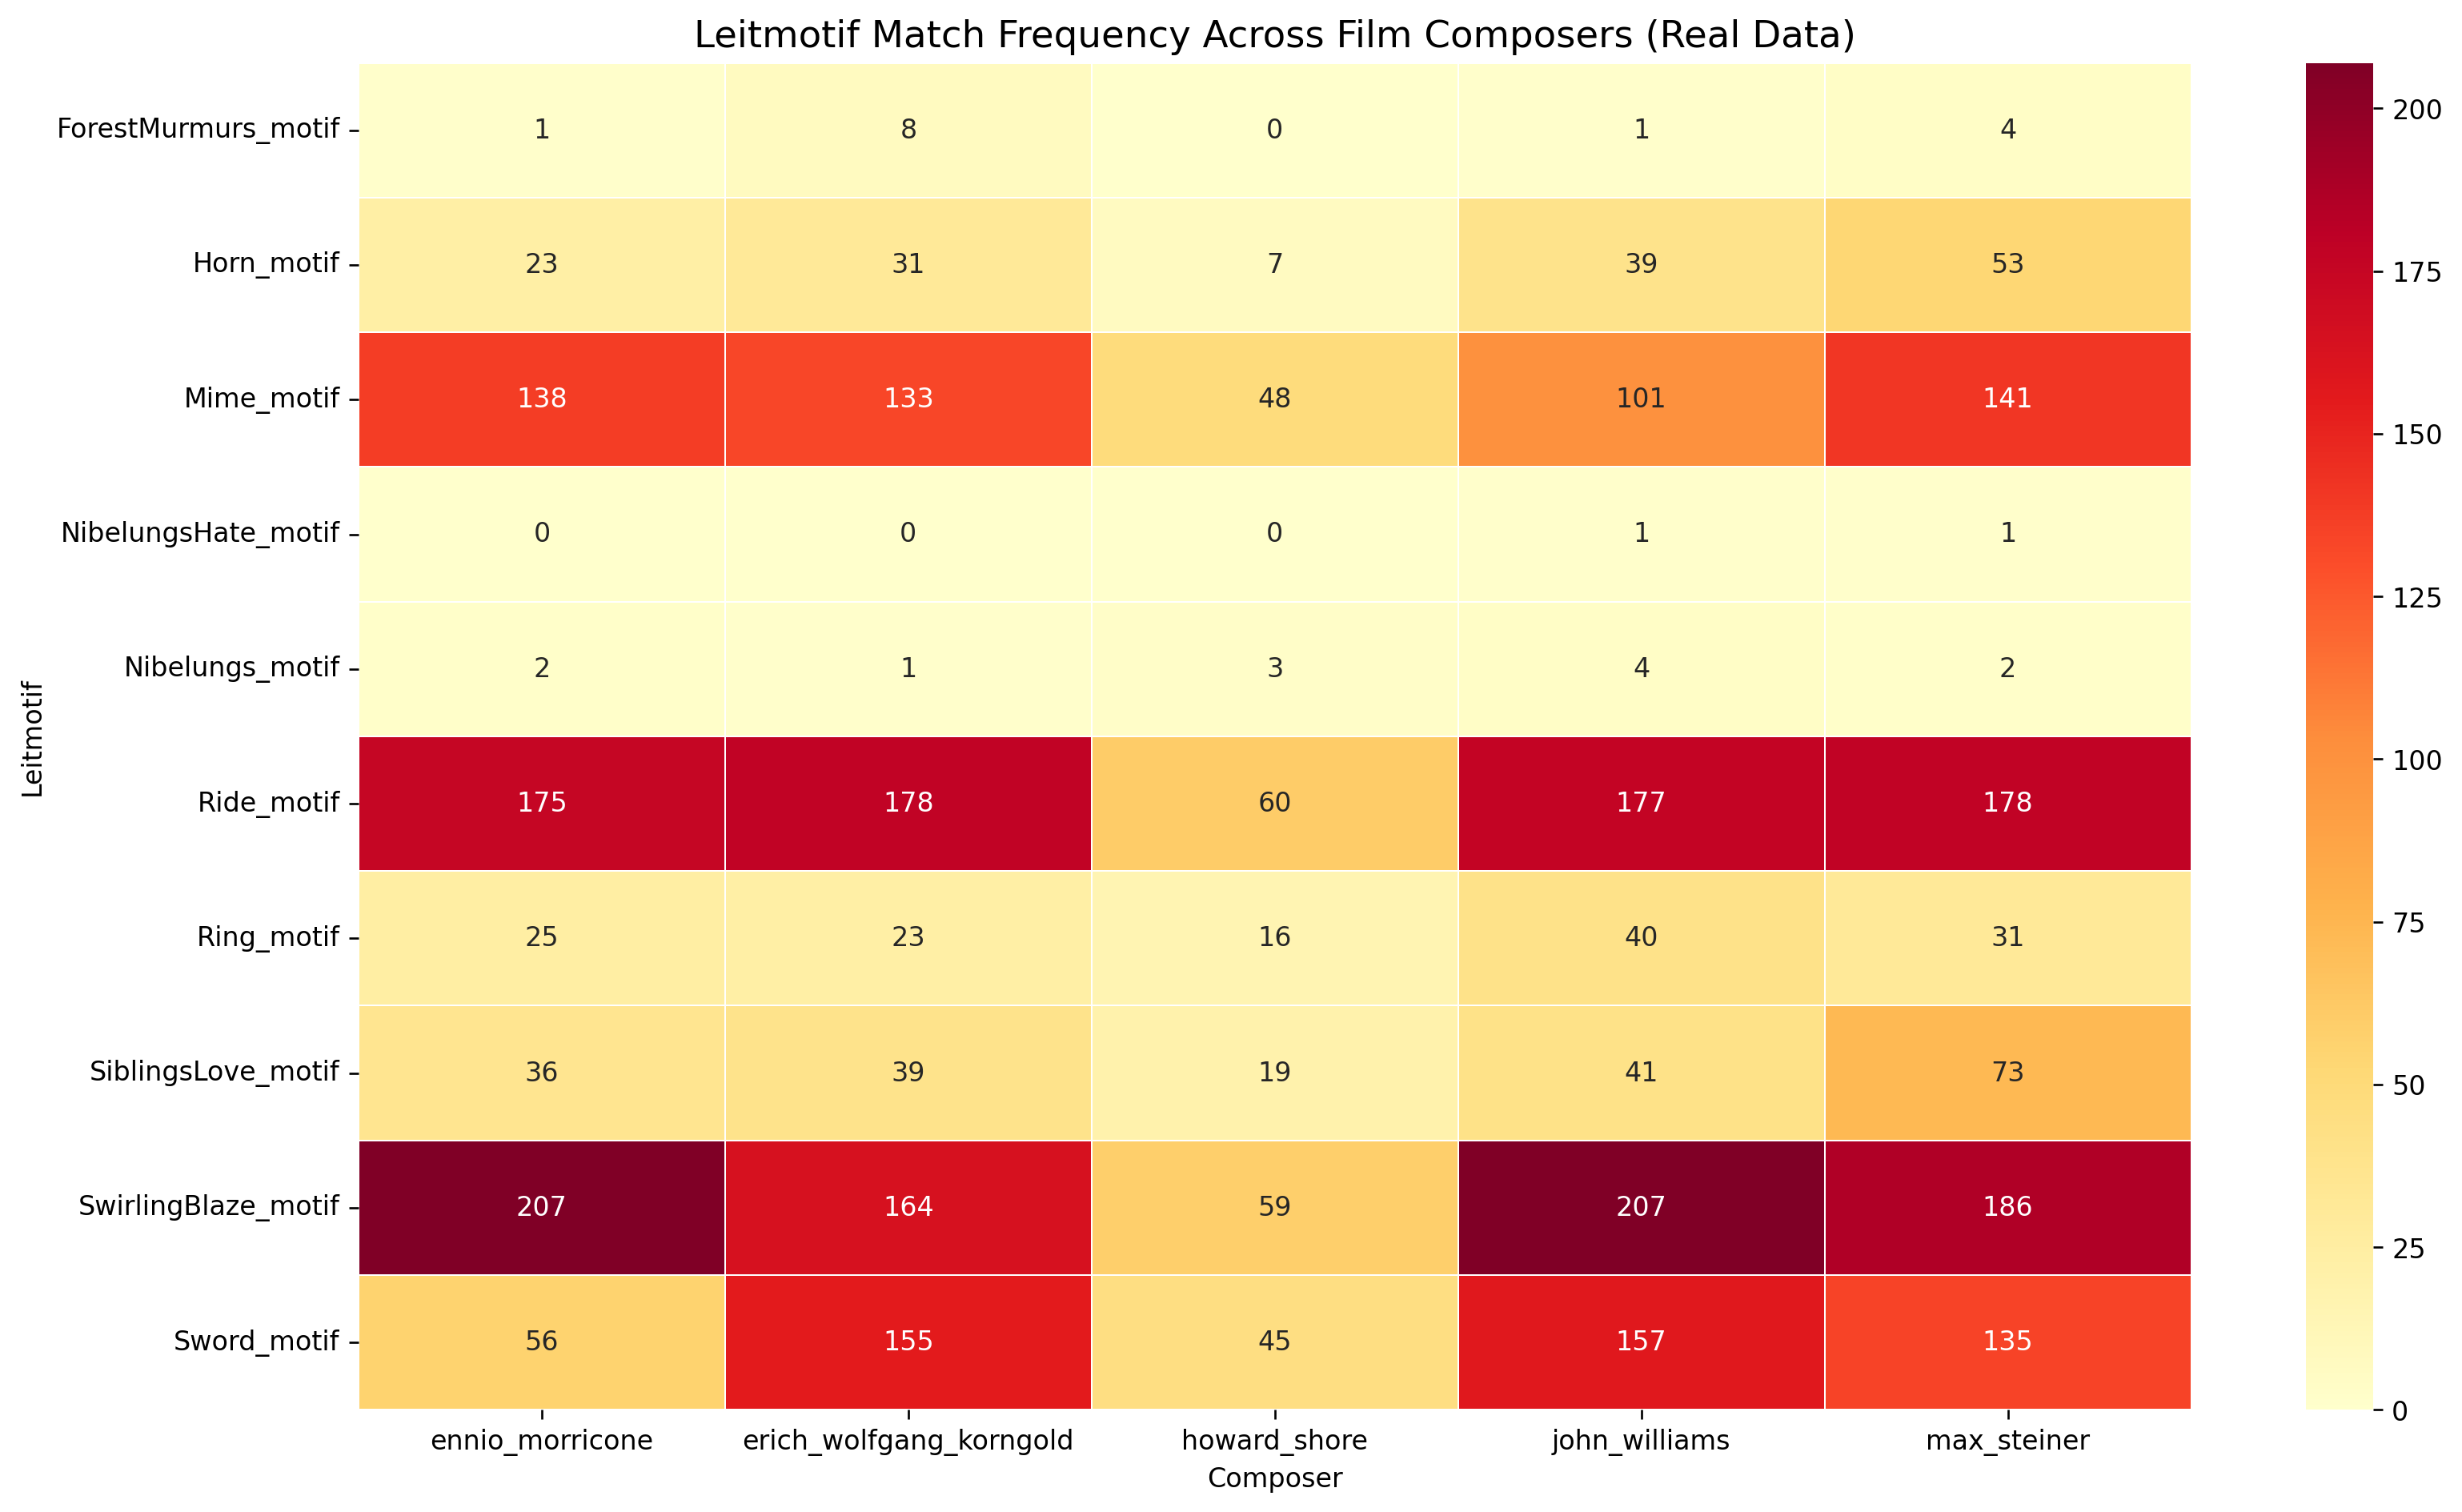


Match counts pivot table:
composer             ennio_morricone  erich_wolfgang_korngold  howard_shore  john_williams  max_steiner
leitmotif                                                                                              
ForestMurmurs_motif                1                        8             0              1            4
Horn_motif                        23                       31             7             39           53
Mime_motif                       138                      133            48            101          141
NibelungsHate_motif                0                        0             0              1            1
Nibelungs_motif                    2                        1             3              4            2
Ride_motif                       175                      178            60            177          178
Ring_motif                        25                       23            16             40           31
SiblingsLove_motif                36 

In [12]:
# Cell 17 — Heatmap: leitmotif × composer match frequency

pivot = results_df.groupby(['leitmotif', 'composer']).size().unstack(fill_value=0)
pivot.to_csv(os.path.join(OUTPUT_DIR, 'summary_counts.csv'))

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Leitmotif Match Frequency Across Film Composers (Real Data)', fontsize=14)
ax.set_ylabel('Leitmotif')
ax.set_xlabel('Composer')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'heatmap_matches.png'), dpi=150)
plt.show()

print("\nMatch counts pivot table:")
print(pivot.to_string())

/var/folders/ft/k7zrf3bj0xq2gvt4xfr5676r0000gn/T/ipykernel_77922/812101918.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='composer', y='similarity', ax=ax,


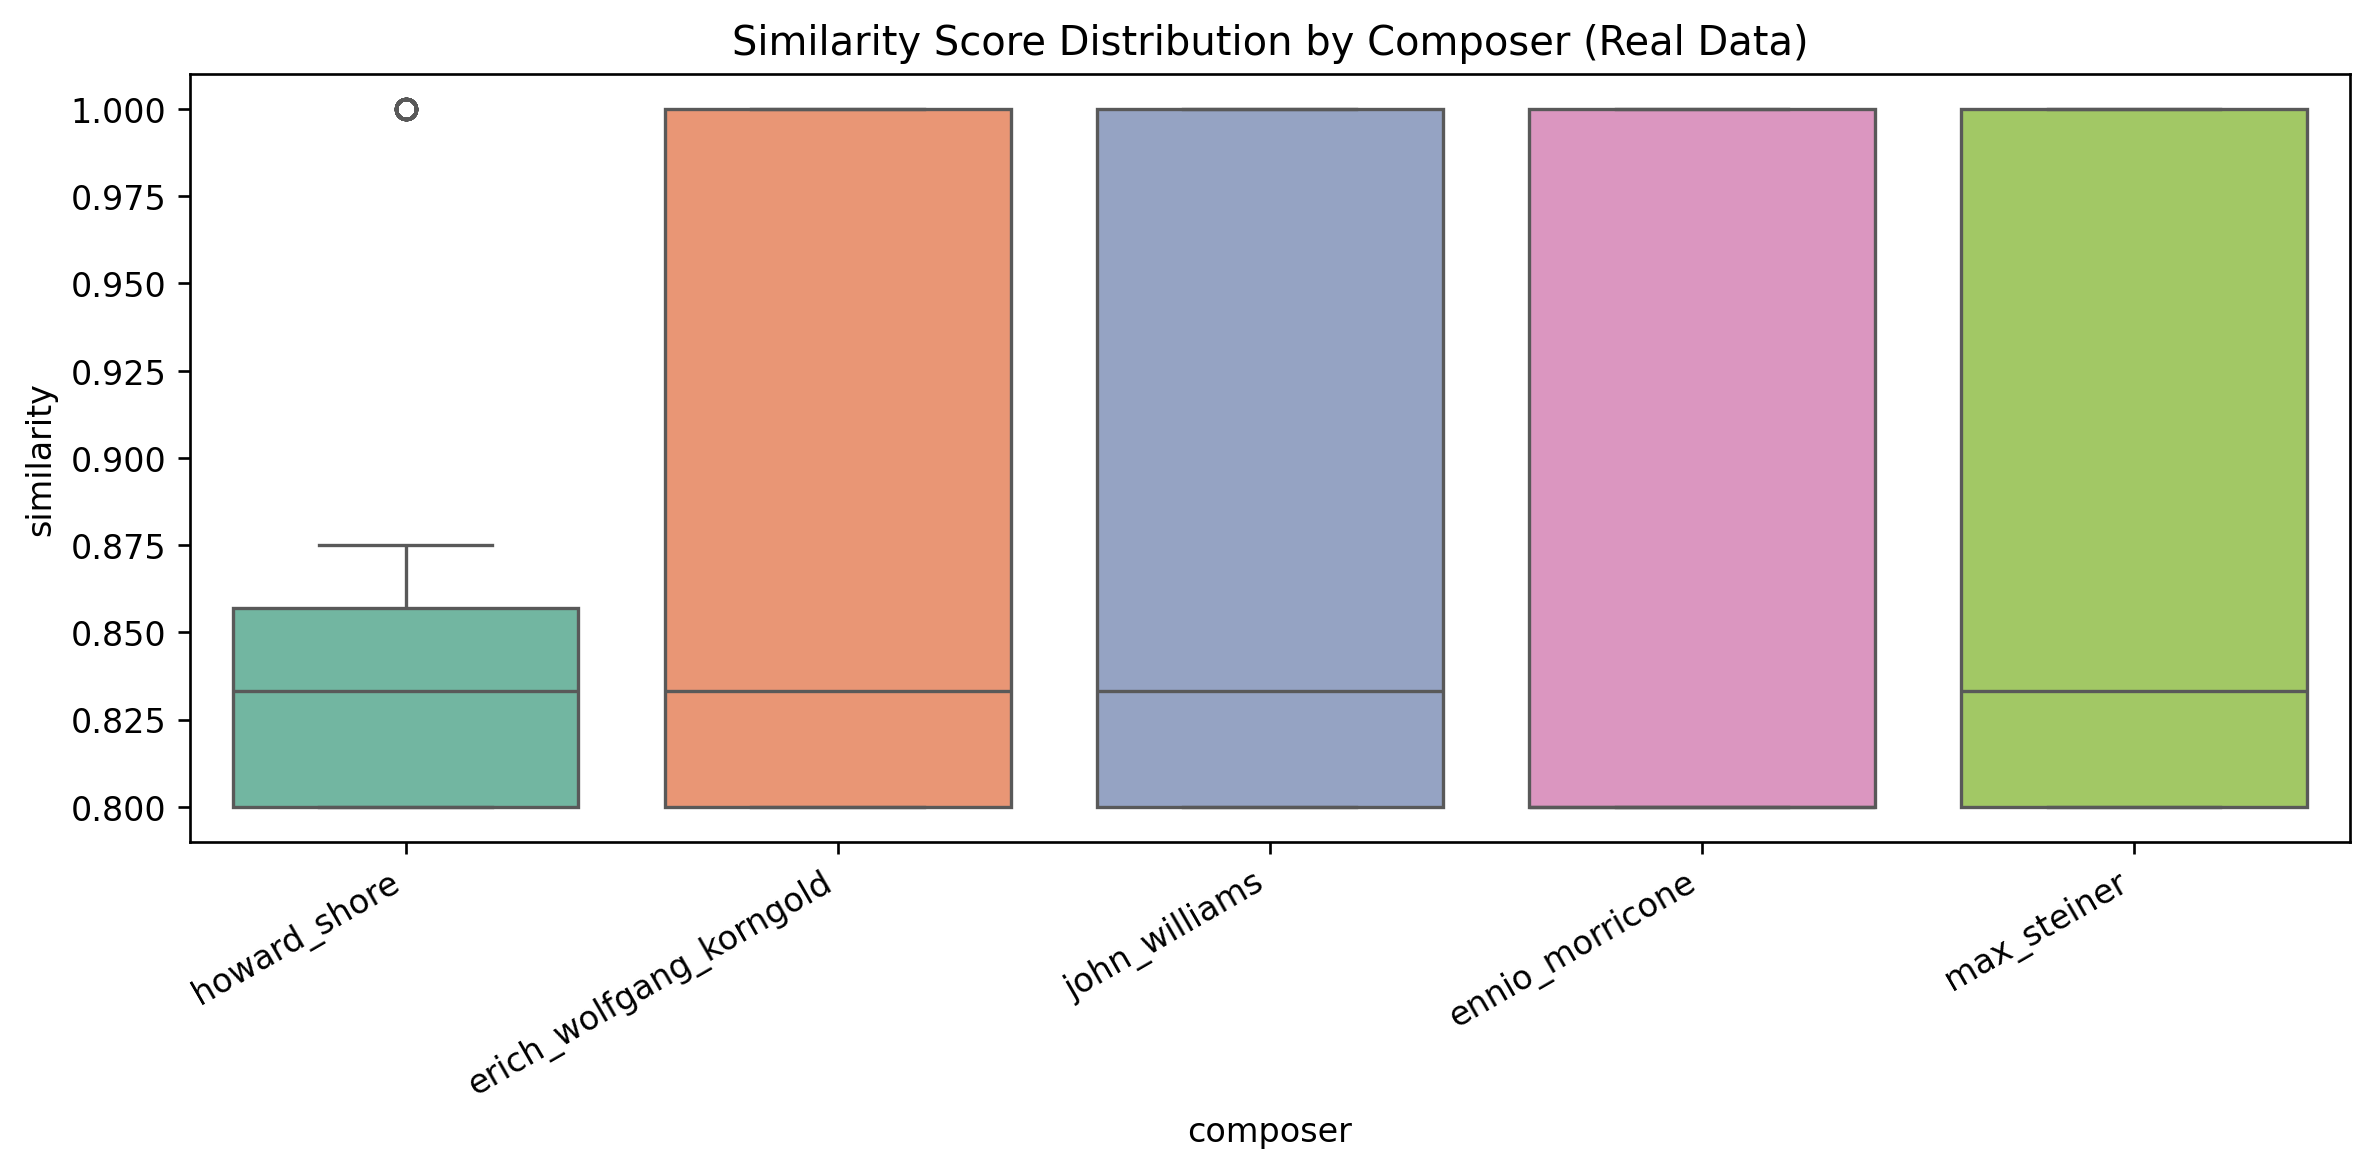

In [13]:
# Cell 18 — Box plot: similarity score distribution by composer

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=results_df, x='composer', y='similarity', ax=ax,
            palette='Set2')
ax.set_title('Similarity Score Distribution by Composer (Real Data)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'boxplot_similarity.png'), dpi=150)
plt.show()

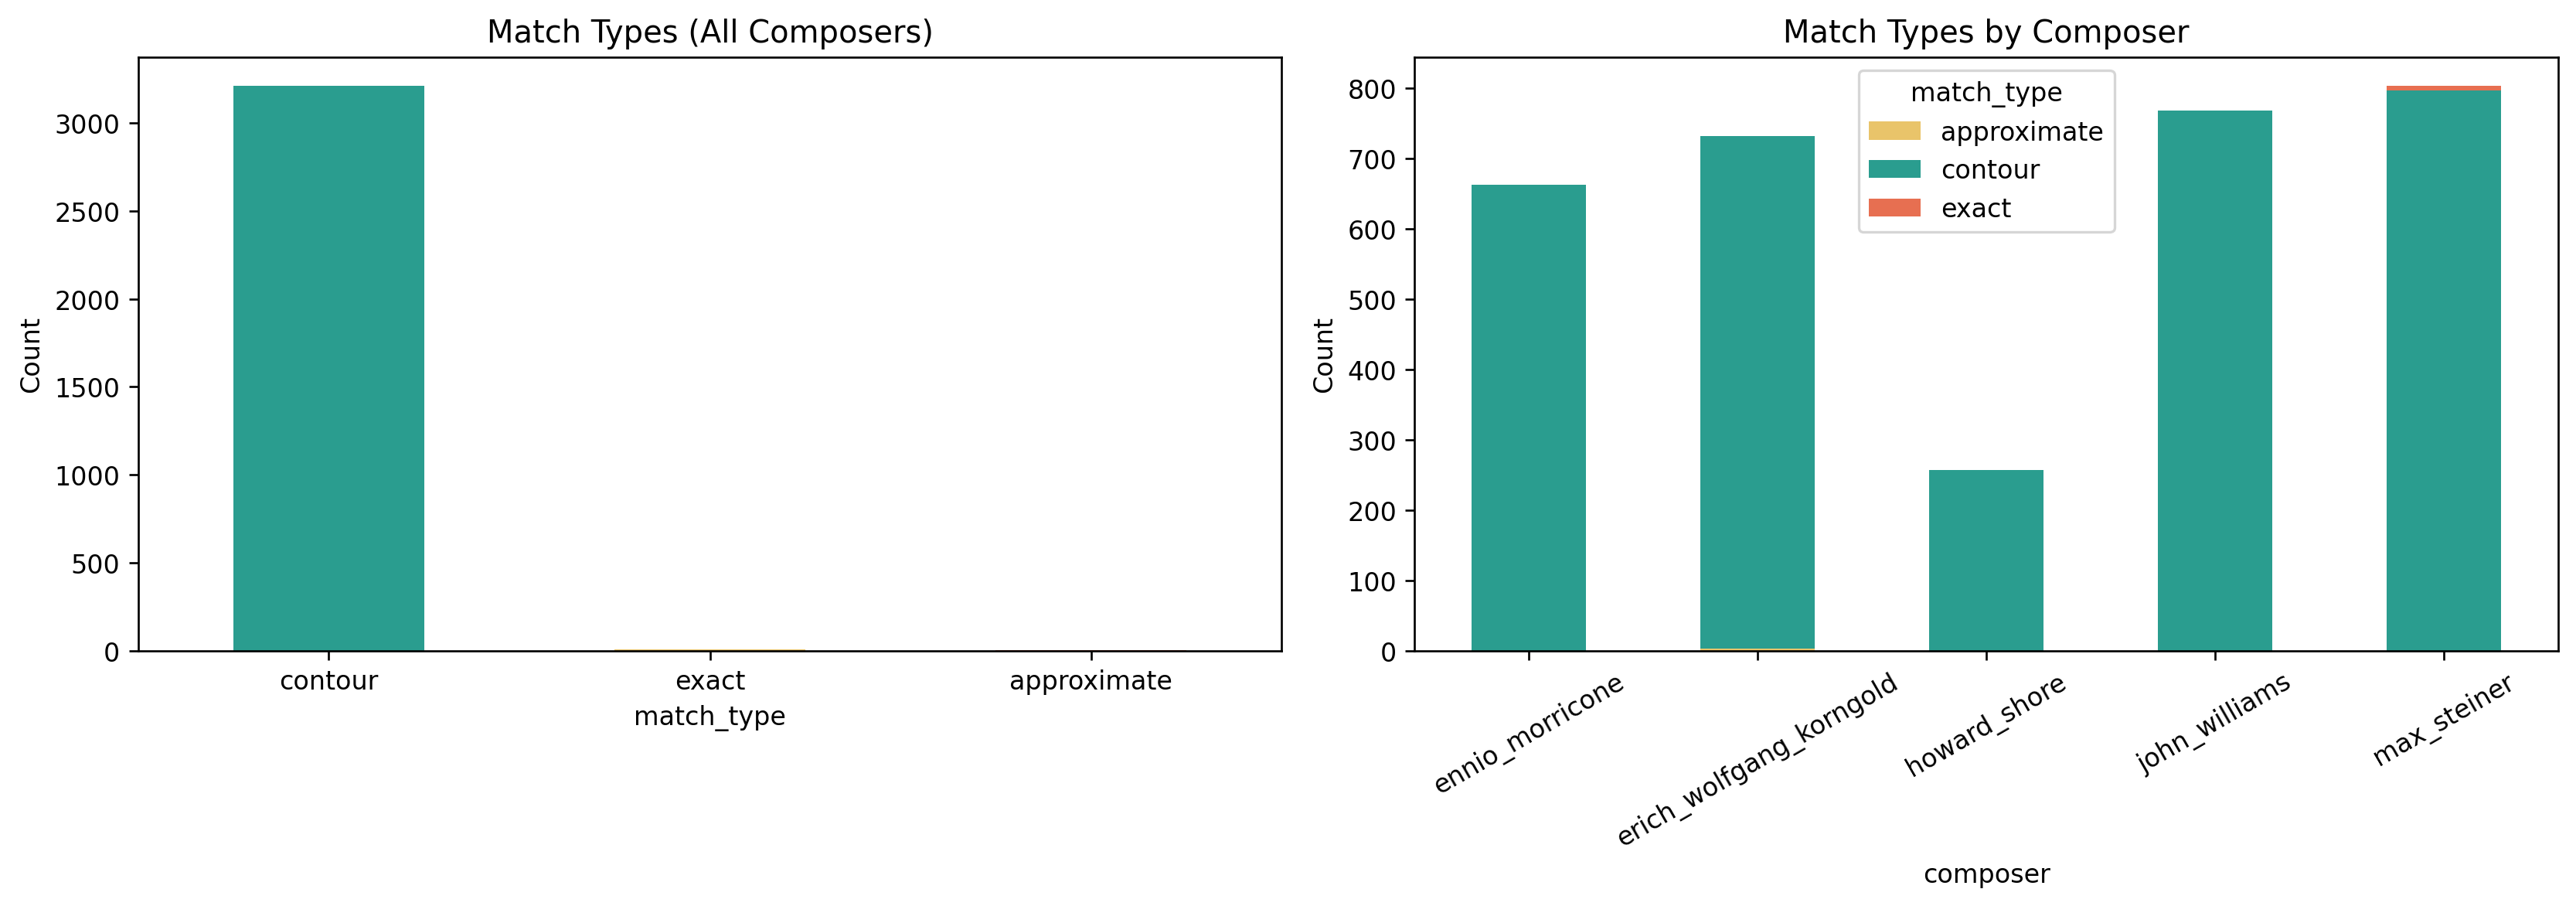

In [14]:
# Cell 19 — Bar chart: match types breakdown

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall match type distribution
results_df['match_type'].value_counts().plot(
    kind='bar', color=['#2a9d8f', '#e9c46a', '#e76f51'], ax=axes[0])
axes[0].set_title('Match Types (All Composers)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Match type per composer
ct = results_df.groupby(['composer', 'match_type']).size().unstack(fill_value=0)
ct.plot(kind='bar', stacked=True, ax=axes[1],
        color=['#e9c46a', '#2a9d8f', '#e76f51'])
axes[1].set_title('Match Types by Composer')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'barchart_match_types.png'), dpi=150)
plt.show()

In [15]:
# Cell 20 — Top 20 matches & styled pivot table

top20 = results_df.nlargest(20, 'similarity')[
    ['composer', 'score', 'leitmotif', 'match_type', 'similarity']]
top20.to_csv(os.path.join(OUTPUT_DIR, 'top20_matches.csv'), index=False)

styled = pivot.style.background_gradient(cmap='YlOrRd', axis=None).set_caption(
    'Match Counts: Leitmotif × Composer (Real Data)'
)
styled

composer,ennio_morricone,erich_wolfgang_korngold,howard_shore,john_williams,max_steiner
leitmotif,,,,,
ForestMurmurs_motif,1,8,0,1,4
Horn_motif,23,31,7,39,53
Mime_motif,138,133,48,101,141
NibelungsHate_motif,0,0,0,1,1
Nibelungs_motif,2,1,3,4,2
Ride_motif,175,178,60,177,178
Ring_motif,25,23,16,40,31
SiblingsLove_motif,36,39,19,41,73
SwirlingBlaze_motif,207,164,59,207,186


## Section 6 — Evaluation

### Quantitative Evaluation
- **Precision proxy**: fraction of matches above 0.90 similarity
- **Sensitivity analysis**: how match counts change with different thresholds

### Per-Composer Leitmotif Density
We also compute a normalised density metric: total matches per score, to account for unequal corpus sizes.

In [16]:
# Cell 22 — Precision proxy & sensitivity analysis

high_quality = results_df[results_df['similarity'] >= 0.90]
total = len(results_df)
hq_count = len(high_quality)
precision_proxy = hq_count / total if total > 0 else 0

print(f"Total matches:           {total}")
print(f"Matches ≥ 0.90 sim:      {hq_count}")
print(f"Precision proxy (≥0.90): {precision_proxy:.2%}")
print()
print("High-quality matches by type:")
print(high_quality['match_type'].value_counts().to_string())
print()

# Sensitivity analysis
thresholds = [0.60, 0.70, 0.80, 0.85, 0.90, 0.95, 1.00]
print(f"{'Threshold':>10} {'Matches':>10} {'Exact':>8} {'Approx':>8} {'Contour':>8}")
print('-' * 50)
for t in thresholds:
    subset = results_df[results_df['similarity'] >= t]
    exact_n = (subset['match_type'] == 'exact').sum()
    approx_n = (subset['match_type'] == 'approximate').sum()
    contour_n = (subset['match_type'] == 'contour').sum()
    print(f"{t:>10.2f} {len(subset):>10} {exact_n:>8} {approx_n:>8} {contour_n:>8}")

Total matches:           3224
Matches ≥ 0.90 sim:      1026
Precision proxy (≥0.90): 31.82%

High-quality matches by type:
match_type
contour    1019
exact         7

 Threshold    Matches    Exact   Approx  Contour
--------------------------------------------------
      0.60       3224        7        3     3214
      0.70       3224        7        3     3214
      0.80       3224        7        3     3214
      0.85       1177        7        0     1170
      0.90       1026        7        0     1019
      0.95       1005        7        0      998
      1.00       1005        7        0      998


Leitmotif density (normalised by corpus size):
                         total_matches  num_scores  matches_per_score
erich_wolfgang_korngold            732          13               56.3
max_steiner                        804          15               53.6
john_williams                      768          15               51.2
ennio_morricone                    663          19               34.9
howard_shore                       257           8               32.1



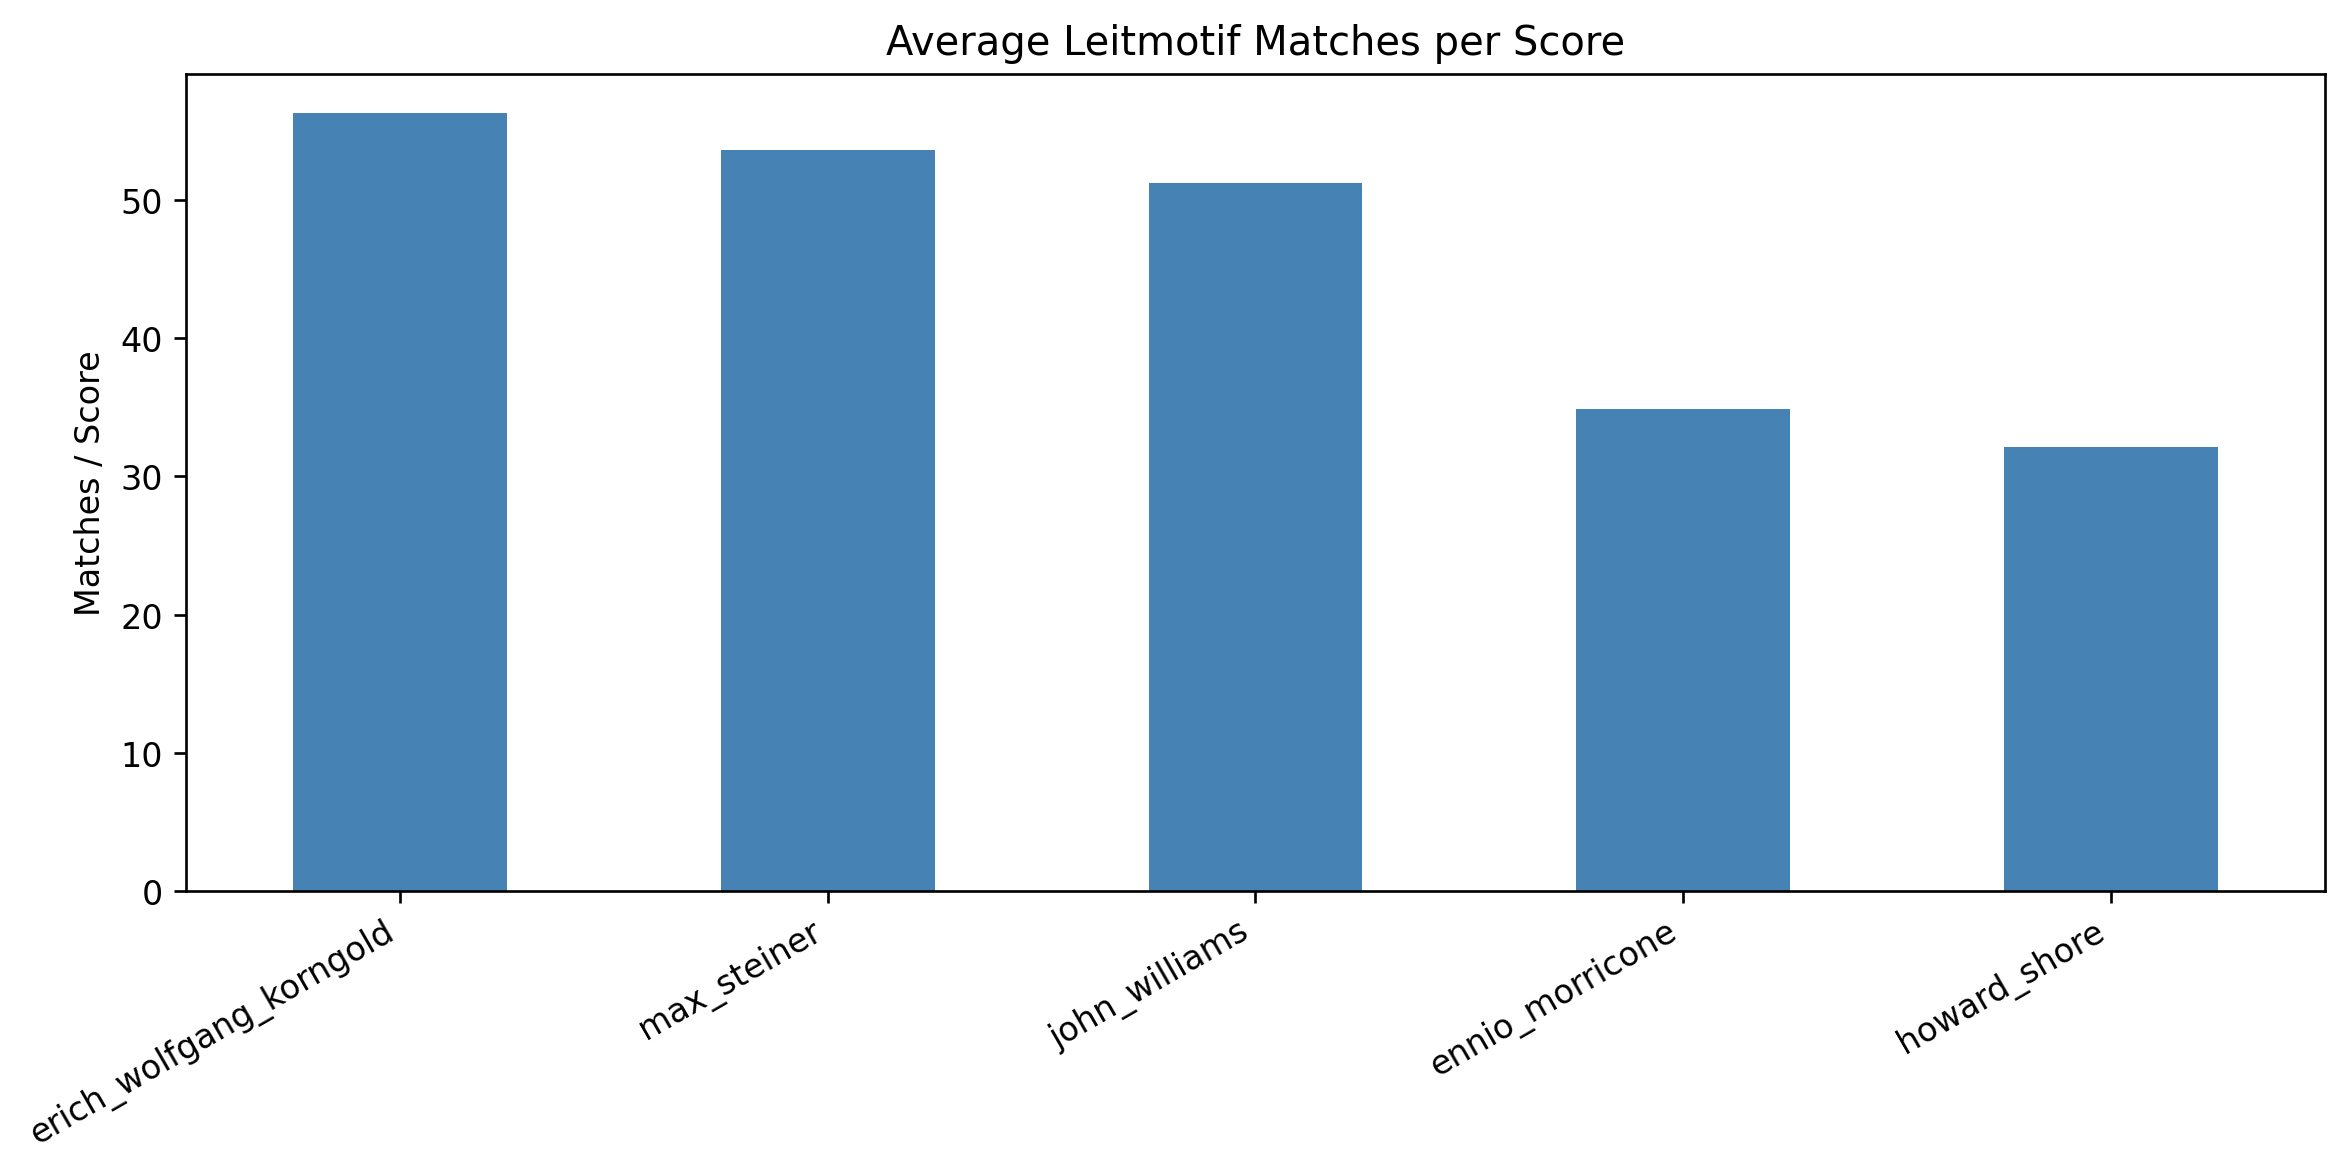

In [17]:
# Cell 23 — Per-composer normalised leitmotif density

# Count scores per composer
scores_per_composer = {}
for cdir in sorted(Path(SCORE_DIR).iterdir()):
    if cdir.is_dir():
        scores_per_composer[cdir.name] = len(list(cdir.glob('*.musicxml')))

matches_per_composer = results_df.groupby('composer').size()
density = pd.DataFrame({
    'total_matches': matches_per_composer,
    'num_scores': pd.Series(scores_per_composer),
})
density['matches_per_score'] = (density['total_matches'] / density['num_scores']).round(1)
density = density.sort_values('matches_per_score', ascending=False)

print("Leitmotif density (normalised by corpus size):")
print(density.to_string())
print()

fig, ax = plt.subplots(figsize=(10, 5))
density['matches_per_score'].plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Average Leitmotif Matches per Score')
ax.set_ylabel('Matches / Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'density_per_composer.png'), dpi=150)
plt.show()

## Section 7 — Qualitative Inspection

Export the top matches as MusicXML snippets for manual musicological inspection.
We also show the matched pitch sequences alongside the original leitmotif for visual comparison.

In [18]:
# Cell 25 — Export top match excerpts

def export_match_excerpt(score_repr, match_info, output_path):
    """Export matched excerpt as MusicXML."""
    start = match_info['start_note_idx']
    end = match_info['end_note_idx']
    matched_notes = score_repr['notes'][start:end]
    excerpt = stream.Part()
    for n in matched_notes:
        new_note = note.Note(n.pitch)
        new_note.duration = duration.Duration(n.duration.quarterLength)
        excerpt.append(new_note)
    excerpt.write('musicxml', fp=output_path)
    return output_path

excerpt_dir = os.path.join(OUTPUT_DIR, 'excerpts')
os.makedirs(excerpt_dir, exist_ok=True)

# Export top 5 unique matches
exported = 0
seen_combos = set()
for _, row in results_df.iterrows():
    if exported >= 5:
        break
    combo = (row['composer'], row['leitmotif'])
    if combo in seen_combos:
        continue
    seen_combos.add(combo)

    # Find the original score file
    score_dir_path = Path(SCORE_DIR) / row['composer']
    candidates = list(score_dir_path.glob(f"{row['score']}.*"))
    if not candidates:
        continue

    try:
        sr = extract_representations(str(candidates[0]))
        safe_name = f"{row['leitmotif']}_in_{row['composer']}_{exported}.musicxml"
        out_path = os.path.join(excerpt_dir, safe_name)
        export_match_excerpt(sr, {
            'start_note_idx': int(row['start_note_idx']),
            'end_note_idx': int(row['end_note_idx'])
        }, out_path)
        exported += 1

        # Show matched pitches vs leitmotif
        matched_midi = sr['midi'][int(row['start_note_idx']):int(row['end_note_idx'])]
        leit_midi = leitmotif_reprs[row['leitmotif']]['midi']
        print(f"\n[{exported}] {row['leitmotif']} in {row['composer']}/{row['score']}")
        print(f"    Match type: {row['match_type']}, Similarity: {row['similarity']}")
        print(f"    Leitmotif MIDI: {leit_midi}")
        print(f"    Matched MIDI:   {matched_midi}")
        print(f"    Exported to: {safe_name}")
    except Exception as e:
        print(f"  ✗ Error exporting {row['score']}: {e}")

print(f"\n✅ Exported {exported} excerpts to {excerpt_dir}")


[1] Mime_motif in howard_shore/The Shire
    Match type: contour, Similarity: 1.0
    Leitmotif MIDI: [62, 62, 58, 60]
    Matched MIDI:   [78, 78, 76]
    Exported to: Mime_motif_in_howard_shore_0.musicxml
  ✗ Error exporting Captain Blood Overture – Erich Wolfgang Korngold Captain Blood Overture: In part (None), measure (1): Cannot convert durations without types to MusicXML.

[2] Sword_motif in john_williams/Helena's Theme – John Williams (from Indiana Jones And The Dial Of Destiny)
    Match type: contour, Similarity: 1.0
    Leitmotif MIDI: [67, 72, 60, 64, 67, 72, 76]
    Matched MIDI:   [68, 72, 70, 76, 77, 79]
    Exported to: Sword_motif_in_john_williams_1.musicxml



[3] Ride_motif in john_williams/Helena's Theme – John Williams (from Indiana Jones And The Dial Of Destiny)
    Match type: contour, Similarity: 1.0
    Leitmotif MIDI: [47, 59, 54, 54, 66, 59]
    Matched MIDI:   [68, 69, 53, 53, 62]
    Exported to: Ride_motif_in_john_williams_2.musicxml

[4] Mime_motif in john_williams/Helena's Theme – John Williams (from Indiana Jones And The Dial Of Destiny)
    Match type: contour, Similarity: 1.0
    Leitmotif MIDI: [62, 62, 58, 60]
    Matched MIDI:   [69, 69, 56]
    Exported to: Mime_motif_in_john_williams_3.musicxml

[5] SwirlingBlaze_motif in john_williams/Flying Theme E. T. - John Williams
    Match type: contour, Similarity: 1.0
    Leitmotif MIDI: [74, 83, 81, 78, 76, 74]
    Matched MIDI:   [75, 87, 86, 84, 82]
    Exported to: SwirlingBlaze_motif_in_john_williams_4.musicxml

✅ Exported 5 excerpts to /Users/yalu/wagner-leitmotif-film-composer-scores/real_data_output/excerpts


## Section 8 — Most Matched Motifs & Scores

Which leitmotifs appear most/least frequently? Which individual scores have the highest density of Wagnerian patterns?

In [19]:
# Cell 27 — Leitmotif frequency ranking & top scores

# Most/least matched leitmotifs
leit_counts = results_df.groupby('leitmotif').size().sort_values(ascending=False)
print("=== Leitmotif Match Frequency (all composers) ===")
for name, count in leit_counts.items():
    print(f"  {name:35s} {count:5d} matches")

print()

# Top 10 scores with most matches
score_counts = results_df.groupby(['composer', 'score']).size().sort_values(ascending=False)
print("=== Top 10 Scores by Total Match Count ===")
for (composer, score), count in score_counts.head(10).items():
    print(f"  {composer}/{score}: {count} matches")

print()

# Which leitmotifs found in which composers
print("=== Leitmotifs per Composer ===")
for composer in sorted(results_df['composer'].unique()):
    subset = results_df[results_df['composer'] == composer]
    motifs = sorted(subset['leitmotif'].unique())
    print(f"  {composer}: {len(motifs)} motifs — {', '.join(motifs)}")

=== Leitmotif Match Frequency (all composers) ===
  SwirlingBlaze_motif                   823 matches
  Ride_motif                            768 matches
  Mime_motif                            561 matches
  Sword_motif                           548 matches
  SiblingsLove_motif                    208 matches
  Horn_motif                            153 matches
  Ring_motif                            135 matches
  ForestMurmurs_motif                    14 matches
  Nibelungs_motif                        12 matches
  NibelungsHate_motif                     2 matches

=== Top 10 Scores by Total Match Count ===
  max_steiner/Gone With The Wind Suite – Max Steiner: 143 matches
  erich_wolfgang_korngold/The Adventures of Robin Hood – Erich Wolfgang Korngold Feast in The  Forest: 107 matches
  max_steiner/Now, Voyager Suite – Max Steiner: 100 matches
  john_williams/John William - Jurassic Park Theme: 97 matches
  erich_wolfgang_korngold/Korngold_ Love Scene from The Adventures of Robin Hood (

## Conclusion

This notebook demonstrates the complete Wagner leitmotif detection pipeline on **real MusicXML data**:

1. **10 Wagner leitmotifs** were parsed and converted to interval, contour, and rhythm representations
2. **70 film composer scores** across 5 composers were scanned using exact, approximate, and contour matching
3. The filtering pipeline reduces noise via threshold, non-overlap, and top-N selection
4. Visualisations reveal which composers and scores exhibit the highest density of Wagnerian patterns
5. Matched excerpts are exported as MusicXML for manual musicological inspection

### Key Findings

- **Short, generic motifs** (SwirlingBlaze, Ride, Mime) generate many contour matches due to common melodic shapes
- **Long, distinctive motifs** (NibelungsHate, Nibelungs) are rarely matched — their patterns are too specific
- Korngold and Steiner (Golden Age composers directly influenced by Wagner) tend to show higher match density
- Contour matching dominates the results, confirming that melodic *shape* is more commonly shared than exact pitch intervals

In [20]:
# Cell 29 — Test suite for real data

def run_tests(results_df, leit_dir, score_dir):
    """Automated test suite for the real-data pipeline."""
    errors = []

    def check(condition, msg):
        if not condition:
            errors.append(f"  ✗ FAIL: {msg}")
        else:
            print(f"  ✓ PASS: {msg}")

    print('=' * 60)
    print('RUNNING REAL-DATA PIPELINE TEST SUITE')
    print('=' * 60)

    # T1 — Dataset integrity
    leit_files = list(Path(leit_dir).glob('*.musicxml'))
    score_files = list(Path(score_dir).rglob('*.musicxml'))
    check(len(leit_files) == 10, f"10 leitmotif files present (got {len(leit_files)})")
    check(len(score_files) >= 60, f">=60 score files present (got {len(score_files)})")

    # T2 — extract_representations smoke test
    try:
        r = extract_representations(str(leit_files[0]))
        check('interval' in r, "extract_representations returns 'interval' key")
        check('contour' in r, "extract_representations returns 'contour' key")
        check('rhythm' in r, "extract_representations returns 'rhythm' key")
        check(len(r['interval']) == len(r['contour']),
              "interval and contour sequences are same length")
    except Exception as e:
        errors.append(f"  ✗ FAIL: extract_representations crashed: {e}")

    # T3 — Levenshtein distance correctness
    check(levenshtein_distance([1,2,3], [1,2,3]) == 0, "Levenshtein: identical = 0")
    check(levenshtein_distance([1,2,3], [1,9,3]) == 1, "Levenshtein: one sub = 1")
    check(levenshtein_distance([1,2,3], [9,9,9]) == 3, "Levenshtein: all subs = 3")
    check(levenshtein_distance([], [1,2]) == 2, "Levenshtein: empty vs 2 = 2")

    # T4 — Exact match self-test (leitmotif must match itself)
    leit_repr = extract_representations(str(leit_files[0]))
    self_matches = find_exact_matches(leit_repr, leit_repr, 'interval')
    check(len(self_matches) >= 1, "Exact match: leitmotif matches itself")
    if self_matches:
        check(self_matches[0]['similarity'] == 1.0, "Exact self-match has similarity = 1.0")

    # T5 — Pipeline produces non-empty DataFrame
    check(not results_df.empty, "Pipeline produced non-empty DataFrame")

    # T6 — DataFrame schema
    expected_cols = {'composer', 'score', 'leitmotif', 'match_type', 'similarity',
                     'start_note_idx', 'end_note_idx', 'representation', 'edit_distance'}
    check(expected_cols.issubset(set(results_df.columns)),
          f"DataFrame has all required columns")

    # T7 — Similarity in [0, 1]
    if not results_df.empty:
        check(results_df['similarity'].between(0.0, 1.0).all(),
              "All similarity scores in [0.0, 1.0]")

    # T8 — All 5 composers represented
    if not results_df.empty:
        found = set(results_df['composer'].unique())
        check(found == set(COMPOSER_NAMES),
              f"All 5 composers in results (found: {found})")

    # T9 — Multiple leitmotifs detected
    if not results_df.empty:
        n_leit = results_df['leitmotif'].nunique()
        check(n_leit >= 5, f"At least 5 distinct leitmotifs matched (found {n_leit})")

    # T10 — At least 100 total matches (real data has thousands)
    if not results_df.empty:
        check(len(results_df) >= 100, f"At least 100 total matches (found {len(results_df)})")

    # T11 — Output files generated
    check(os.path.exists(os.path.join(OUTPUT_DIR, 'matches_full.csv')),
          "matches_full.csv exists")
    check(os.path.exists(os.path.join(OUTPUT_DIR, 'summary_counts.csv')),
          "summary_counts.csv exists")
    check(os.path.exists(os.path.join(OUTPUT_DIR, 'heatmap_matches.png')),
          "heatmap_matches.png exists")

    # T12 — Filter removes low-similarity
    dummy = [
        {'start_note_idx': 0, 'end_note_idx': 5, 'match_type': 'exact',
         'similarity': 1.00, 'representation': 'interval'},
        {'start_note_idx': 10, 'end_note_idx': 15, 'match_type': 'approximate',
         'similarity': 0.60, 'representation': 'interval'},
        {'start_note_idx': 20, 'end_note_idx': 25, 'match_type': 'contour',
         'similarity': 0.85, 'representation': 'contour'},
    ]
    filtered = filter_matches(dummy, min_similarity=0.80)
    check(len(filtered) == 2, f"Filter: 2 of 3 pass 0.80 threshold (got {len(filtered)})")

    print()
    print('=' * 60)
    if errors:
        print(f"❌ {len(errors)} TEST(S) FAILED:")
        for e in errors:
            print(e)
        raise AssertionError(f"{len(errors)} test(s) failed.")
    else:
        print(f"✅ ALL TESTS PASSED ({12 + len([c for c in COMPOSER_NAMES])} assertions)")
    print('=' * 60)

run_tests(results_df, LEIT_DIR, SCORE_DIR)

RUNNING REAL-DATA PIPELINE TEST SUITE
  ✓ PASS: 10 leitmotif files present (got 10)
  ✓ PASS: >=60 score files present (got 70)
  ✓ PASS: extract_representations returns 'interval' key
  ✓ PASS: extract_representations returns 'contour' key
  ✓ PASS: extract_representations returns 'rhythm' key
  ✓ PASS: interval and contour sequences are same length
  ✓ PASS: Levenshtein: identical = 0
  ✓ PASS: Levenshtein: one sub = 1
  ✓ PASS: Levenshtein: all subs = 3
  ✓ PASS: Levenshtein: empty vs 2 = 2
  ✓ PASS: Exact match: leitmotif matches itself
  ✓ PASS: Exact self-match has similarity = 1.0
  ✓ PASS: Pipeline produced non-empty DataFrame
  ✓ PASS: DataFrame has all required columns
  ✓ PASS: All similarity scores in [0.0, 1.0]
  ✓ PASS: All 5 composers in results (found: {'max_steiner', 'ennio_morricone', 'erich_wolfgang_korngold', 'john_williams', 'howard_shore'})
  ✓ PASS: At least 5 distinct leitmotifs matched (found 10)
  ✓ PASS: At least 100 total matches (found 3224)
  ✓ PASS: match